# ECG Signal Classification: Normal Sinus Rhythm (NSR) vs. Congestive Heart Failure (CHF)

**Objective:** The goal of this project is to build an end-to-end Machine Learning pipeline to classify ECG signals.We will go through data collection, preprocessing, exploratory data analysis (EDA), and modeling to compare the performance of different algorithms.

## Step 1 & 2: Data Collection and Preprocessing
In this section, we will:
1. Import the necessary libraries.
2. Load the dataset into a pandas DataFrame.
3. Handle any missing values (NaNs) by imputing them with the mean value of their respective columns.

In [36]:
## Importing Required Libraries 

# Data handling and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset and Handling Missing Values

Before visualizing our data, it is crucial to clean it. We will load the dataset and immediately check for any missing values (NaNs).If any are found, we will replace them with the mean value of that specific feature to ensure our visualizations and subsequent models work perfectly without dropping valuable data points.

In [37]:
# 1. Load the dataset

df = pd.read_excel('ECG_Data.xlsx')

# printing first 5 rows of the data
df.head()



,category,EA4,ED1,ED2,ED3,ED4,RLF,RMF,RHF,Afo,SDNN,RMSSD,Alpha1,ApEn,SampEn
0,CHF,0.751853,0.004129,0.014499,0.043069,0.186450,0.984746,0.014494,0.000760,0.294878,0.019652,0.032572,0.369900,0.401595,0.534677
1,CHF,0.741436,0.004632,0.021419,0.049147,0.183365,0.983666,0.014950,0.001385,0.292235,0.070824,0.062731,-3.207133,0.556204,0.743826
2,CHF,0.808035,0.003446,0.013181,0.049631,0.125707,0.981508,0.017136,0.001356,0.309725,0.066086,0.061763,1.910956,0.671427,1.003302
3,CHF,0.758219,0.003643,0.017234,0.044219,0.176685,0.988153,0.011432,0.000415,0.281318,0.082614,0.099138,1.111752,0.453715,0.873003
4,CHF,0.734342,0.003856,0.020027,0.052353,0.189422,0.987408,0.012010,0.000582,0.291465,0.086443,0.077340,NaN,0.664267,1.015231


In [38]:
# Describing Our Data
df.describe()

,EA4,ED1,ED2,ED3,ED4,RLF,RMF,RHF,Afo,SDNN,RMSSD,Alpha1,ApEn,SampEn
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1655.000000,1800.000000,1773.000000
mean,0.456776,0.027275,0.135868,0.207430,0.172650,0.907359,0.084029,0.008612,0.398756,0.099199,0.133217,0.937074,0.348011,0.904938
std,0.225212,0.034463,0.112683,0.103984,0.076397,0.100751,0.091336,0.015505,0.240969,0.157883,0.230150,1.581409,0.179768,0.500098
min,0.058143,0.000048,0.000422,0.002225,0.005583,0.377814,0.000297,0.000042,0.054329,0.000000,0.000000,-10.453784,-0.057158,0.000000
25%,0.267391,0.004904,0.035351,0.124436,0.118376,0.852450,0.012120,0.001168,0.220193,0.036713,0.035387,0.366612,0.221822,0.602175
50%,0.451514,0.014931,0.107916,0.211404,0.164139,0.940032,0.055278,0.003284,0.344504,0.068460,0.089739,0.807080,0.346099,0.785049
75%,0.637987,0.040878,0.223632,0.290102,0.221066,0.985862,0.131603,0.010043,0.498931,0.108854,0.146952,1.349987,0.479303,1.189962
max,0.990349,0.358205,0.519382,0.476032,0.457985,0.999655,0.563872,0.309711,1.593514,2.491859,3.597736,10.275672,0.803345,2.624669


In [39]:
# Print missing values before imputation
print("Missing values BEFORE imputation:")
print(df.isnull().sum())

# 1. Remove duplicate rows
# Check how many duplicate rows exist in the dataset
print("\nNumber of duplicate rows BEFORE removal:", df.duplicated().sum())

# Remove duplicate rows from the DataFrame
df = df.drop_duplicates()

# Confirm duplicates after removal
print("Number of duplicate rows AFTER removal:", df.duplicated().sum())

# 2. Handle missing values
# Select only numerical columns to safely compute mean values
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Fill missing values (NaNs) in numerical columns with their mean values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


# Print missing values after imputation
print("\nMissing values AFTER imputation:")
print(df.isnull().sum())

Missing values BEFORE imputation:
category      0
EA4           0
ED1           0
ED2           0
ED3           0
ED4           0
RLF           0
RMF           0
RHF           0
Afo           0
SDNN          0
RMSSD         0
Alpha1      145
ApEn          0
SampEn       27
dtype: int64

Number of duplicate rows BEFORE removal: 0
Number of duplicate rows AFTER removal: 0

Missing values AFTER imputation:
category    0
EA4         0
ED1         0
ED2         0
ED3         0
ED4         0
RLF         0
RMF         0
RHF         0
Afo         0
SDNN        0
RMSSD       0
Alpha1      0
ApEn        0
SampEn      0
dtype: int64


## Exploratory Data Analysis (EDA) & Visualization

Now that the data is clean and missing values are handled, we will explore the dataset using `matplotlib` and `seaborn`. 
We will generate the following plots[cite: 6, 14]:
1. **Target Distribution (Countplot):** To check if our classes (NSR vs. CHF) are balanced.
2. **Feature Distributions (Histograms & Boxplots):** To observe the spread of the data and detect potential outliers.
3. **Correlation Heatmap:** To understand the linear relationships between different numerical features.

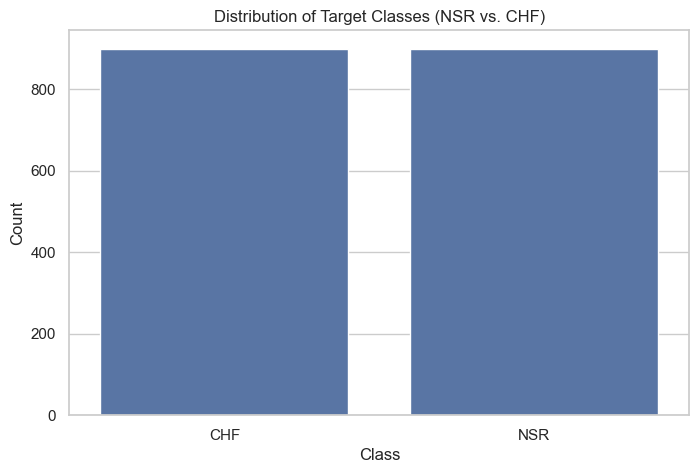

In [40]:

# Visualization 1: Target Variable Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='category')
plt.title('Distribution of Target Classes (NSR vs. CHF)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()



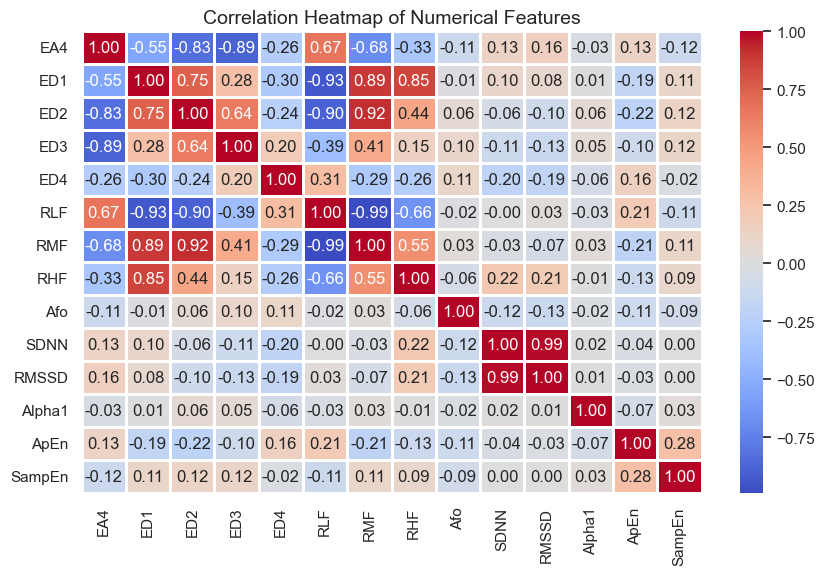

In [41]:

#Correlation Heatmap for chossing the best features

plt.figure(figsize=(10, 6))
# Calculate the correlation matrix for numerical columns
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, linecolor='white')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

## Step 3: Feature Selection and Distribution (KDE Plots)

Based on the correlation heatmap, several features are highly correlated (e.g., SDNN and RMSSD have a correlation of 0.99). To avoid multicollinearity and simplify our models, we will select a subset of features that are relatively independent. 

**Selected Features:** `SDNN`, `ApEn`, `SampEn`, `EA4`, `ED4`, `Afo`, `Alpha1`.

Before feeding these features to our models, we will plot Kernel Density Estimate (KDE) plots to understand their distributions across our target (NSR vs. CHF).

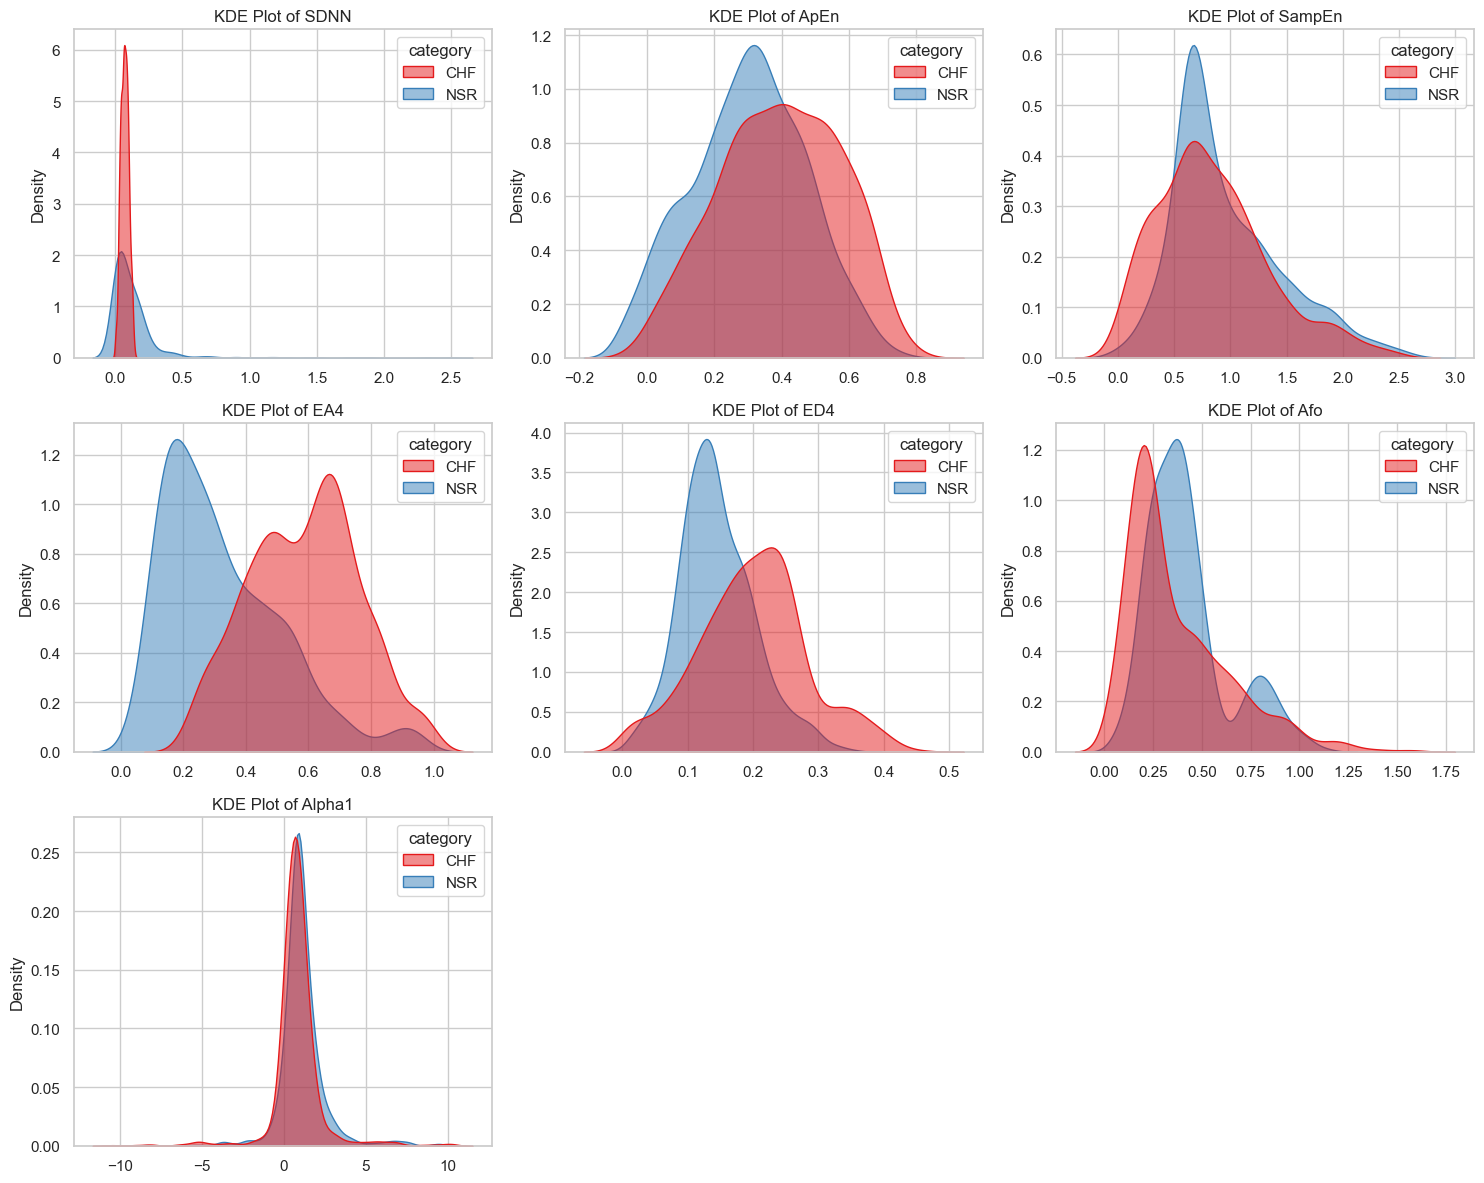

In [42]:

# 1. Select the Best Independent Features
selected_features = ['SDNN', 'ApEn', 'SampEn', 'EA4', 'ED4', 'Afo', 'Alpha1']

# Set up the matplotlib figure for multiple subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# 2. Plot KDE for each selected feature
for i, feature in enumerate(selected_features):
    sns.kdeplot(
        data=df, 
        x=feature, 
        hue='category', 
        fill=True, 
        alpha=0.5, 
        palette='Set1', 
        ax=axes[i]
    )
    axes[i].set_title(f'KDE Plot of {feature}', fontsize=12)
    axes[i].set_xlabel('')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 4: Data Preparation for Modeling

Before training our classifiers (SVM, Decision Tree, and ANN), we must prepare the data:
1. **Define X (features) and y (target):** Using our selected features and the `category` column.
2. **Train/Test Split:** We will split the data (80% training, 20% testing).
3. **Feature Scaling:** We will use `StandardScaler` to normalize the features; As our Algorithms are highly sensitive to the scale of the data.

In [43]:
# our ML library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Define Features (X) and Target (y)
X = df[selected_features]
y = df['category']

# Encode the target variable if it's categorical (e.g., 'NSR' -> 0, 'CHF' -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded #satisfy the y_number while spiliting but actually our data is eq. divided
)

# 3. Feature Scaling
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# (learns mean and std from training set only) learn and apply
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same parameters learned from training
# (do NOT fit on test data to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (1440, 7)
Testing data shape: (360, 7)


## Step 5: Training Traditional Machine Learning Models

We will start by training two classical machine learning algorithms:
1. **Support Vector Machine (SVM):** Excellent for finding complex boundaries in high-dimensional spaces.
2. **Decision Tree Classifier:** A tree-based model that is highly interpretable.

We will evaluate them using Accuracy and a Classification Report (Precision, Recall, F1-Score).

## 1st SVM #

In [44]:
# Import Support Vector Machine classifier
from sklearn.svm import SVC
# Import evaluation metrics (accuracy + detailed report)
from sklearn.metrics import classification_report, accuracy_score

# 1. Train and Evaluate SVM
# Print section header for clarity
print("Support Vector Machine (SVM) Results")

# Initialize SVM model with RBF kernel (non-linear decision boundary)
# random_state ensures reproducibility (the same way each time)
svm_model = SVC(kernel='rbf', random_state=42)

# Train the SVM model using scaled training data
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
svm_preds = svm_model.predict(X_test_scaled)

# Calculate and print accuracy score
print(f"SVM Accuracy: {accuracy_score(y_test, svm_preds):.4f}\n")

# Print precision, recall, f1-score for each class
 # NOTE: le.classes_ contain the original names from the encoder.
print(classification_report(y_test, svm_preds, target_names=le.classes_))


Support Vector Machine (SVM) Results
SVM Accuracy: 0.9417

              precision    recall  f1-score   support

         CHF       0.95      0.93      0.94       180
         NSR       0.93      0.95      0.94       180

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



## 2nd Decision Tree

In [45]:
# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Print section header for Decision Tree results
print(" Decision Tree Classifier Results")

# Initialize Decision Tree model with max depth to avoid overfitting
# random_state ensures reproducibility
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the Decision Tree model using scaled training data
dt_model.fit(X_train_scaled, y_train)

# Predict labels for test data
dt_preds = dt_model.predict(X_test_scaled)

# Calculate and print accuracy score
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.4f}\n")

# Print detailed classification metrics (precision, recall, f1-score)
print(classification_report(y_test, dt_preds, target_names=le.classes_))

 Decision Tree Classifier Results
Decision Tree Accuracy: 0.9333

              precision    recall  f1-score   support

         CHF       0.92      0.94      0.93       180
         NSR       0.94      0.92      0.93       180

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360



## Step 6: Training the Artificial Neural Network (ANN)

NOW, We will build a simple ANN model using `TensorFlow/Keras`. 
* **Input Layer:** Matches the number of our selected features.
* **Hidden Layers:** Two dense layers with `ReLU` activation.
* **Output Layer:** A single neuron with a `Sigmoid` activation function for binary classification.

In [ ]:
# our DL model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Build the ANN Architecture

ann_model = Sequential([
    # Input layer + 1st Hidden Layer
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)), #msut tell teh model in the first layer the num.of features(shape[1])
    Dropout(0.2), # Dropout layer to prevent overfitting
    
    # 2nd Hidden Layer
    Dense(8, activation='relu'),
    
    # Output Layer (Binary classification: 1 neuron, sigmoid activation)
    Dense(1, activation='sigmoid')
])

# 2. Compile the Model

ann_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 3. Train the Model

print(" Training Artificial Neural Network (ANN)")
history = ann_model.fit(
    X_train_scaled, 
    y_train, 
    epochs=50, 
    batch_size=16, 
    validation_split=0.1, # Use 10% of training data for validation
    verbose=0 # Set to 1 to see the training progress per epoch
)

# 4. Evaluate the Model on Test Data

loss, ann_accuracy = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nANN Test Accuracy: {ann_accuracy:.4f}")

# Convert probabilities to binary predictions (0 or 1) for the report
ann_preds_prob = ann_model.predict(X_test_scaled, verbose=0)
ann_preds = (ann_preds_prob > 0.5).astype(int)

print("\n ANN Classification Report")
print(classification_report(y_test, ann_preds, target_names=le.classes_))

 Training Artificial Neural Network (ANN)

ANN Test Accuracy: 0.9639

 ANN Classification Report
              precision    recall  f1-score   support

         CHF       0.97      0.96      0.96       180
         NSR       0.96      0.97      0.96       180

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



## Step 7: Models Comparison & Evaluation

In this final step, we evaluate the performance of our three models (**SVM**, **Decision Tree**, and **ANN**) using the required metrics:
1. **Confusion Matrices:** To visualize the True Positives, True Negatives, False Positives, and False Negatives for each model.
2. **Classification Reports:** A detailed breakdown of Precision, Recall, and F1-Score.
3. **Accuracy Comparison:** A bar graph to provide a clear visual comparison of which model performed best.

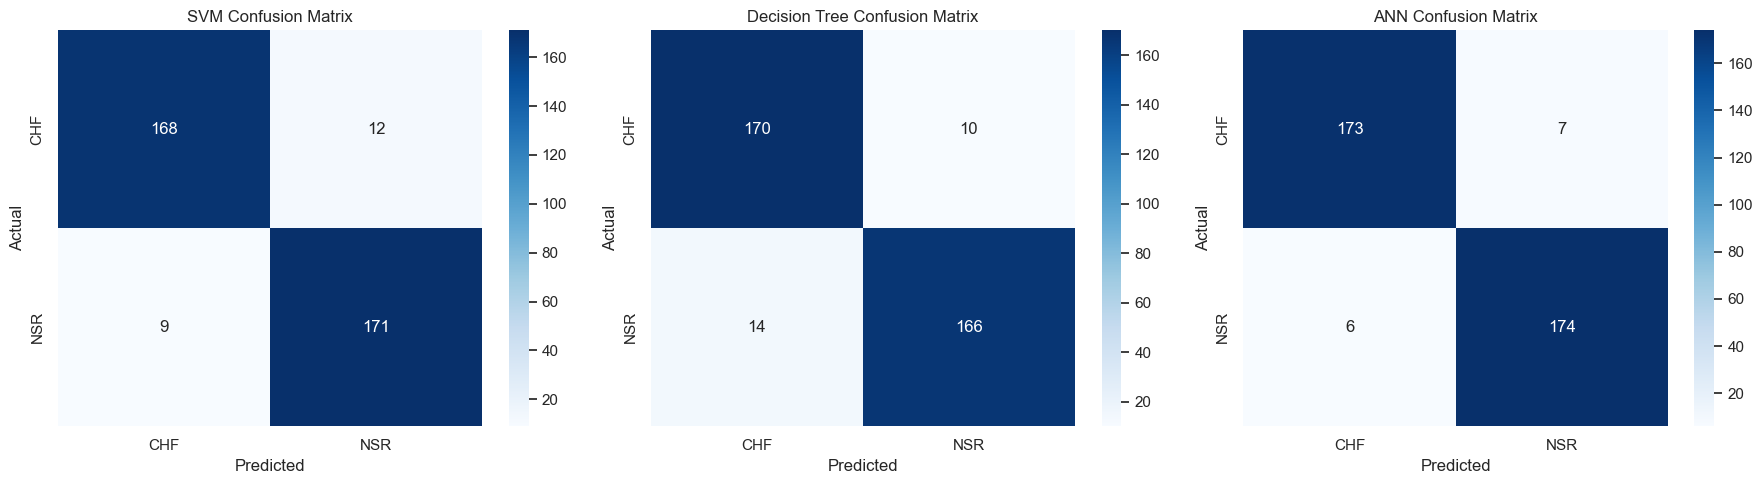


--- SVM Classification Report ---
          precision    recall  f1-score
CHF        0.949153  0.933333  0.941176
NSR        0.934426  0.950000  0.942149
accuracy   0.941667  0.941667  0.941667

--- Decision Tree Classification Report ---
          precision    recall  f1-score
CHF        0.923913  0.944444  0.934066
NSR        0.943182  0.922222  0.932584
accuracy   0.933333  0.933333  0.933333

--- ANN Classification Report ---
          precision    recall  f1-score
CHF        0.966480  0.961111  0.963788
NSR        0.961326  0.966667  0.963989
accuracy   0.963889  0.963889  0.963889


In [ ]:
from sklearn.metrics import confusion_matrix

# 1. Function to Display Classification Report in a Table

def display_report(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(f"\n--- {model_name} Classification Report ---")
    print(report_df.iloc[:3, :3]) # Displaying main metrics

# 2. Plotting Confusion Matrices

models_preds = [svm_preds, dt_preds, ann_preds]
model_names = ['SVM', 'Decision Tree', 'ANN']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (preds, name) in enumerate(zip(models_preds, model_names)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Displaying the text-based reports for detailed analysis
for preds, name in zip(models_preds, model_names):
    display_report(y_test, preds, name)

## Final Performance Summary
We will now plot a bar chart comparing the accuracy of the three models to determine the best performer for this specific ECG dataset.

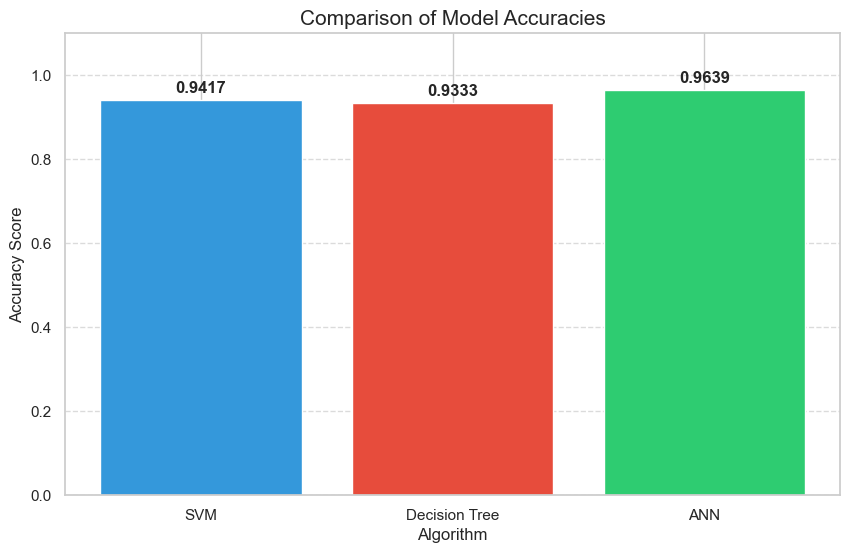

           FINAL MODEL RANKING                
 Model Rank     Algorithm  Accuracy Score
          1           ANN        0.963889
          2           SVM        0.941667
          3 Decision Tree        0.933333
🏆 BEST PERFORMER: ANN with 96.39% Accuracy


In [55]:

# 1. Collect Accuracy Scores
svm_acc = accuracy_score(y_test, svm_preds)
dt_acc = accuracy_score(y_test, dt_preds)
# ann_accuracy was calculated during the ANN training cell

accuracies = [svm_acc, dt_acc, ann_accuracy]

# 2. Plotting the Comparison Bar Graph
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'])

# Adding the exact accuracy value on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', 
             ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1) # Set limit slightly above 1.0 for the labels
plt.title('Comparison of Model Accuracies', fontsize=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Final Conclusion Table
comparison_df = pd.DataFrame({
    'Model Rank': range(1, 4),
    'Algorithm': [x for _, x in sorted(zip(accuracies, model_names), reverse=True)],
    'Accuracy Score': sorted(accuracies, reverse=True)
})

# Identify the winner
best_model = comparison_df.iloc[0]['Algorithm']
best_score = comparison_df.iloc[0]['Accuracy Score']

print("==============================================")
print("           FINAL MODEL RANKING                ")
print("==============================================")
print(comparison_df.to_string(index=False))
print("==============================================")
print(f"🏆 BEST PERFORMER: {best_model} with {best_score:.2%} Accuracy")
print("==============================================")